## Distributions, redundancy and credinality (2a - 2c)

In [7]:
import sys, glob, warnings
warnings.filterwarnings("ignore")
sys.path.append("../../") # lets us import helper.py
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display
from helper import *
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

DATA_FILE = glob.glob("../../data/student_mental_health/*.csv")[0]
TARGET = "Stress_Level"
ORDER = ["Low", "Medium", "High", "Very High"] # natural order of the classes

df = pd.read_csv(DATA_FILE)
# Allowed "datatype fix": the target is text, but it has a natural order; ordered categorical
df[TARGET] = pd.Categorical(df[TARGET], categories=ORDER, ordered=True)
num_cols, cat_cols = split_columns(df, TARGET) # feature lists WITHOUT the target
print(df.shape, "| numeric features:", len(num_cols), "| categorical features:", len(cat_cols))

(5000, 13) | numeric features: 7 | categorical features: 5


## 2a; Distributions and imablance

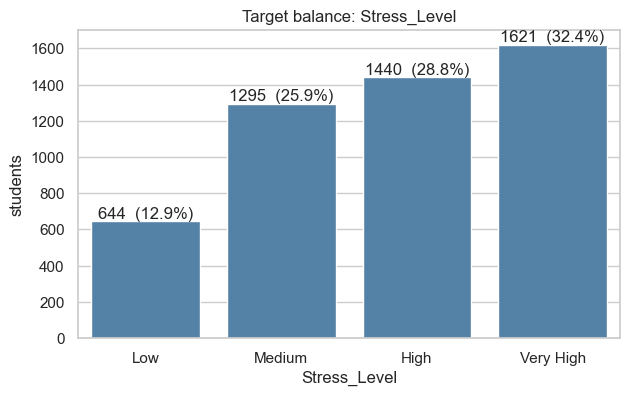

Imbalance ratio (largest / smallest class): 2.52


In [8]:
counts = df[TARGET].value_counts().reindex(ORDER)
plt.figure(figsize=(7,4))
ax = sns.barplot(x=counts.index.astype(str), y=counts.values, color="steelblue")
for i, v in enumerate(counts.values):
    ax.text(i, v + 15, f"{v}  ({v/len(df)*100:.1f}%)", ha="center")
plt.title("Target balance: Stress_Level"); plt.ylabel("students"); plt.show()
print("Imbalance ratio (largest / smallest class):", round(counts.max() / counts.min(), 2))

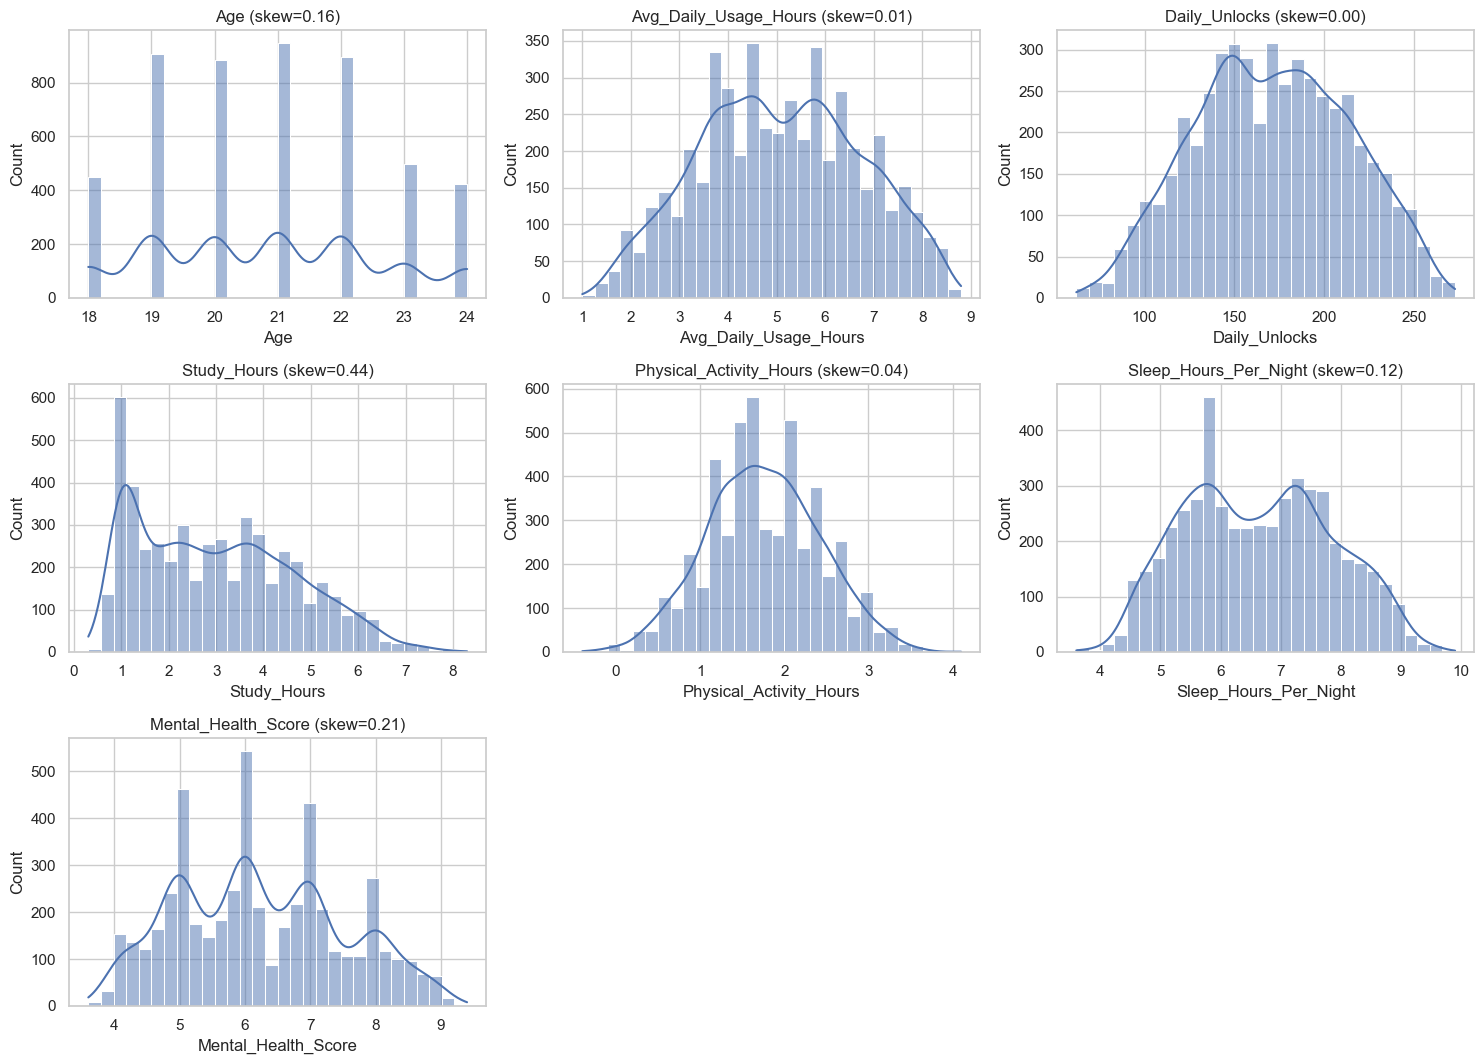

,skew,excess_kurtosis,verdict
Study_Hours,0.436,-0.727,roughly symmetric
Mental_Health_Score,0.207,-0.803,roughly symmetric
Age,0.155,-0.913,roughly symmetric
Sleep_Hours_Per_Night,0.124,-0.879,roughly symmetric
Physical_Activity_Hours,0.040,-0.226,roughly symmetric
Avg_Daily_Usage_Hours,0.006,-0.768,roughly symmetric
Daily_Unlocks,0.002,-0.709,roughly symmetric


In [9]:
hist_grid(df, num_cols)
display(skew_kurt_table(df, num_cols))

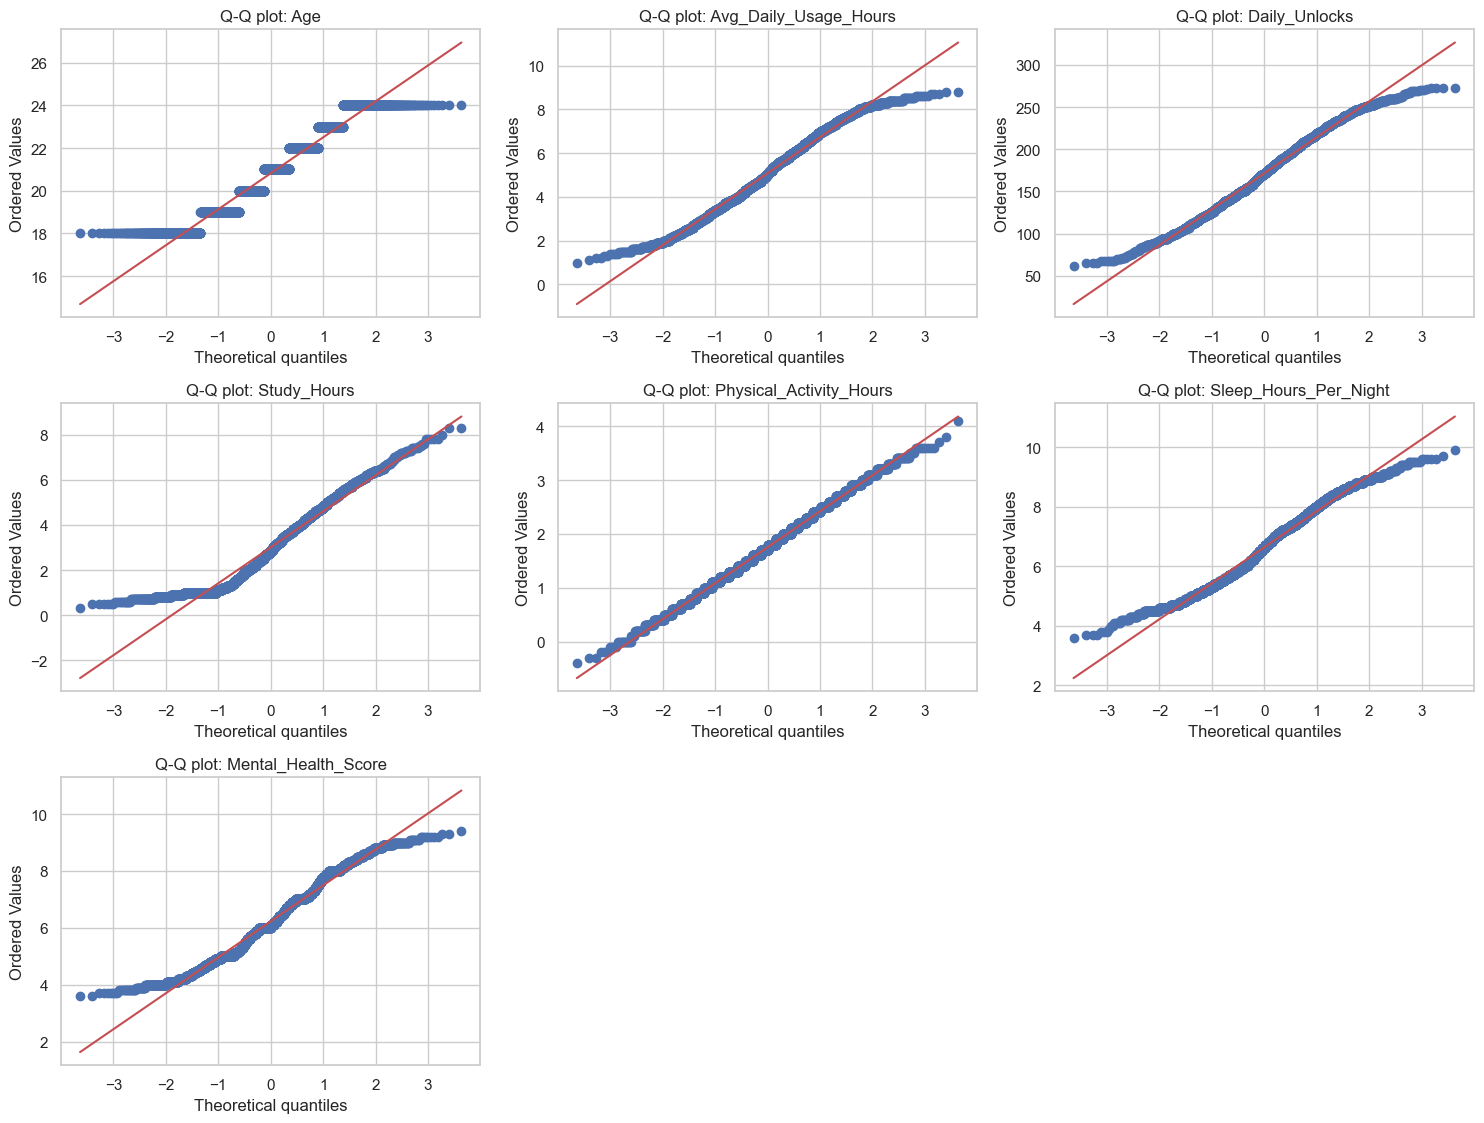

In [10]:
qq_grid(df, num_cols) # points on the red line are normal, if they are on curved ends then those are heavy/light tails.

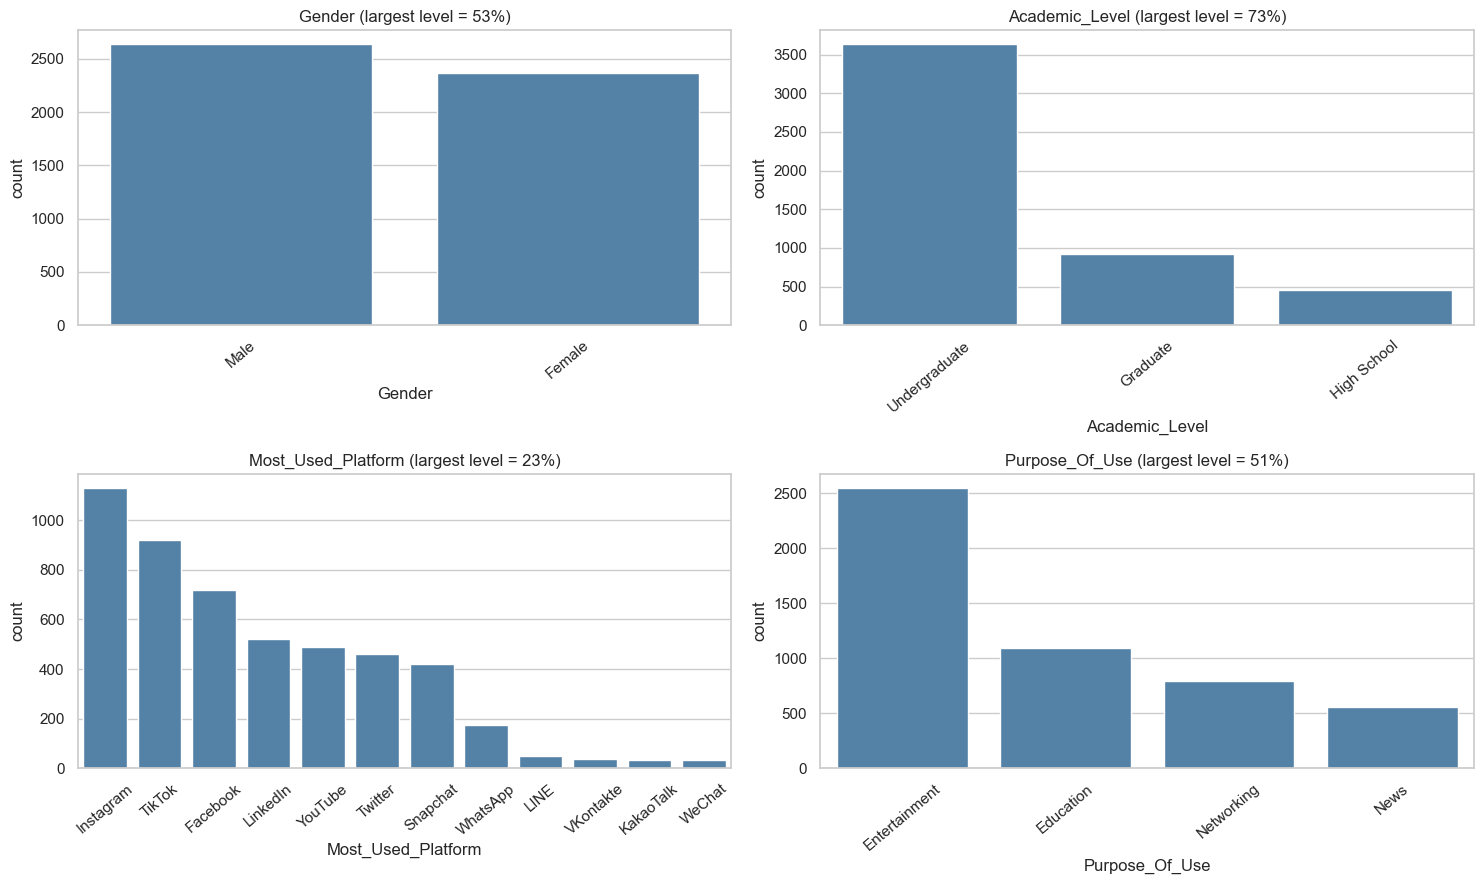

In [11]:
small_cats = [c for c in cat_cols if c != "Country"]
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, col in zip(axes.ravel(), small_cats):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=ax, color="steelblue")
    ax.set_title(f"{col} (largest level = {df[col].value_counts(normalize=True).iloc[0]*100:.0f}%)"); ax.tick_params(axis="x", rotation=40)
plt.tight_layout(); plt.show()

### Conclusions / My findings

Our target is very high, showing up to 1'621 (32.4%), High 1'440 (28.8%), Medium 1'295 (25.9%), Low 644 (12.9%). That means that our ratio is 2.5 : 1. This is moderate imabalnce, but its not extreme. 

Expected effect: a classfier will find `Low` harder; report per-class precision/recall (or macro-F1), not just accurancy, and use stratified splits

#### Numeric Features
There is no distribution problem. The larger skew is `Study_Hours` (+0.44); all the others are bellow 0.25. Excess kurtosis is negative everywhere (-0.2 to -0.9): the features are flatter than the normal curve (platykurtic) - they look close to uniform/bell-ish with short tails, so there are no heavy tails. The Q-Q plots confirms this (the small S-shape at the ends). 

#### Categorical features
`Gender` is balanced (53/47), `Academical_Level` is dominated by Undergraduates (72.6%), `Most_Used_Platfroms` is dominated by Instagram/TikTok/Facebook with multiple tiny platforms, `Purposse_Of_Use` has 4 levels. 


## 2b) Multicollinearity and redundancy

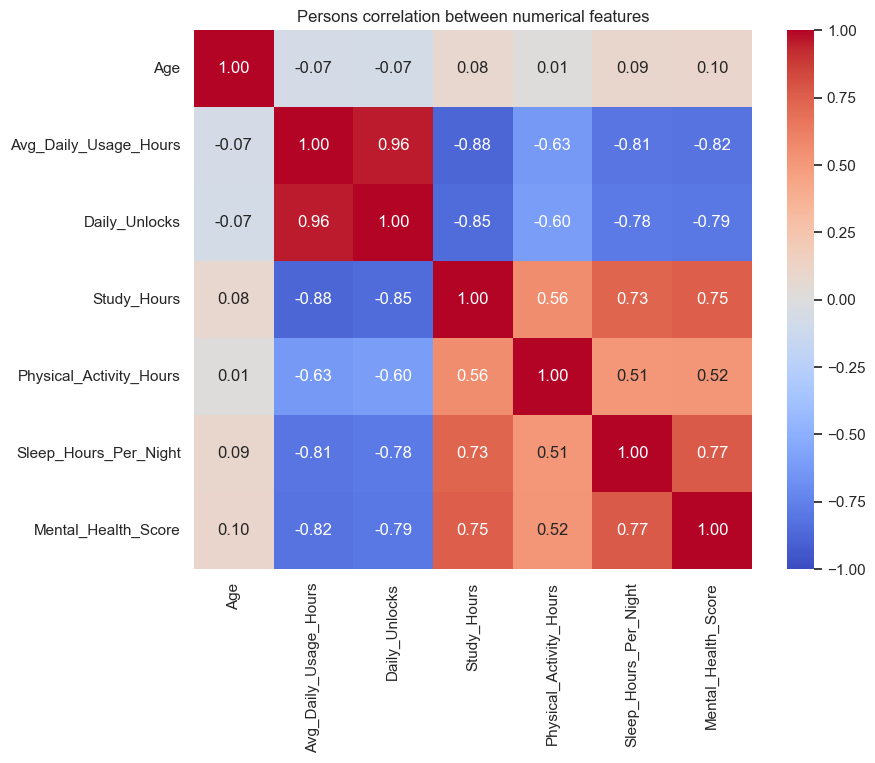

,feature_1,feature_2,abs_corr
0,Avg_Daily_Usage_Hours,Daily_Unlocks,0.960187
1,Avg_Daily_Usage_Hours,Study_Hours,0.878645
2,Daily_Unlocks,Study_Hours,0.853397
3,Avg_Daily_Usage_Hours,Mental_Health_Score,0.816453
4,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,0.808388


,VIF
Avg_Daily_Usage_Hours,17.78
Daily_Unlocks,12.91
Study_Hours,4.49
Mental_Health_Score,3.38
Sleep_Hours_Per_Night,3.21
Physical_Activity_Hours,1.65
Age,1.02


In [12]:
# VIF (Variance Inflation Factor) 10 = Serious, 5-10 = Moderate

plt.figure(figsize=(9,7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Persons correlation between numerical features"); plt.show()
display(high_corr_pairs(df,num_cols, 0.8))
display(vif_table(df, num_cols))

Age,18,19,20,21,22,23,24
Academic_Level,,,,,,,
Graduate,0,0,0,0,0,496,422
High School,450,0,0,0,0,0,0
Undergraduate,0,906,883,947,896,0,0


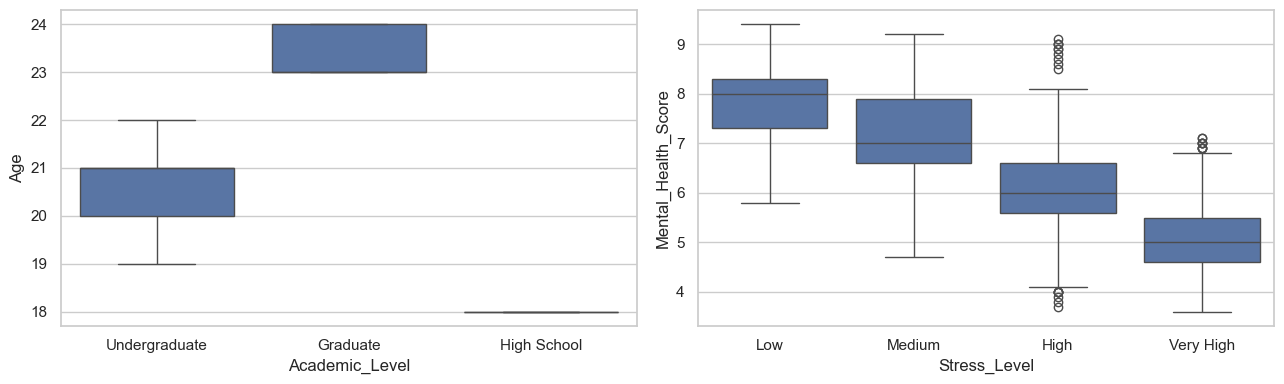

In [13]:
display(pd.crosstab(df["Academic_Level"], df["Age"]))
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=df, x="Academic_Level", y="Age", ax=ax[0])
sns.boxplot(data=df, x=TARGET, y="Mental_Health_Score", order=ORDER, ax=ax[1]); plt.tight_layout(); plt.show()

# 2c) High cardinality
`ninique()`

,unique,unique_%_of_rows,top_value_share_%,rare_levels(<1%)
Country,111,2.22,37.6,88
Most_Used_Platform,12,0.24,22.6,3
Purpose_Of_Use,4,0.08,51.0,0
Academic_Level,3,0.06,72.6,0
Gender,2,0.04,52.7,0


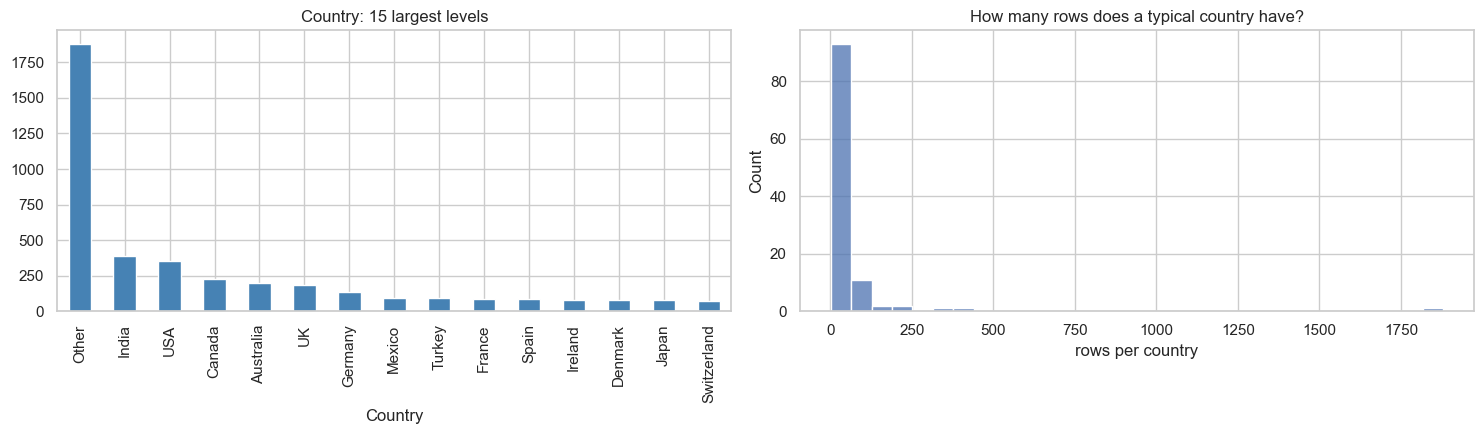

Countries with < 10 rows: 79 | with exactly 1 row: 18


Most_Used_Platform
Instagram    1130
TikTok        918
Facebook      719
LinkedIn      523
YouTube       491
Twitter       462
Snapchat      420
WhatsApp      175
LINE           50
VKontakte      40
KakaoTalk      36
WeChat         36
Name: count, dtype: int64

In [14]:
display(cardinality_table(df, cat_cols))
vc = df["Country"].value_counts()
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
vc.head(15).plot.bar(ax=ax[0], color="steelblue"); ax[0].set_title("Country: 15 largest levels")
sns.histplot(vc.values, bins=30, ax=ax[1]); ax[1].set_title("How many rows does a typical country have?"); ax[1].set_xlabel("rows per country")
plt.tight_layout(); plt.show()
print("Countries with < 10 rows:", int((vc < 10).sum()), "| with exactly 1 row:", int((vc == 1).sum()))
display(df["Most_Used_Platform"].value_counts())